# Figure 4c–f | OOF predictive performance

按当前模型比较结果中各性能的最佳模型绘制 Figure 4c–f。三个回归面板直接使用已保存的 OOF 预测；UL94 使用已保存的每折 XGBoost 参数和相同的 Stratified 5-fold 划分重建 OOF 概率。每个绘图 cell 会显示图片并保存透明背景 SVG。

In [ ]:
# 1. 可调参数、环境和路径
from __future__ import annotations

import json
import os
from pathlib import Path

# 避免 OpenMP/BLAS 线程与 XGBoost 同时过度占用计算资源。
for _name in ('OMP_NUM_THREADS', 'OPENBLAS_NUM_THREADS', 'MKL_NUM_THREADS', 'NUMEXPR_NUM_THREADS'):
    os.environ.setdefault(_name, '1')

import matplotlib.pyplot as plt
from matplotlib import font_manager
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.metrics import auc, mean_squared_error, r2_score, roc_curve
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

# ===== 图形样式（可直接修改） =====
PLOT = {
    # 单张散点图/ROC 图的画幅（英寸）
    'width_in': 3.35,
    'height_in': 3.35,
    # 字体大小（pt）
    'axis_label_size': 12,
    'tick_label_size': 10.5,
    'annotation_size': 10.5,
    'legend_size': 10,
    # 加粗线条与点的尺寸
    'spine_width': 1.65,
    'tick_width': 1.45,
    'tick_length': 4.8,
    'reference_line_width': 1.55,
    'roc_line_width': 2.05,
    'point_size': 12,
    'point_alpha': 0.60,
    # Figure 4 蓝灰—橙色体系；transparent=True 使 SVG 底色透明。
    'point_color': '#F28E16',
    'reference_color': '#9A9A9A',
    'axis_color': '#111111',
    'transparent': True,
    # 坐标范围外扩比例；增大可让点云距边框更远。
    'axis_padding_fraction': 0.04,
    # 回归指标文字位置（Axes 相对坐标）。
    'metric_text_xy': (0.05, 0.95),
}

# True 时若当前最佳模型与论文当前设定不同则中止；更新模型比较后可改为 False。
STRICT_EXPECTED_MODELS = True
EXPECTED_BEST_MODELS = {'LOI': 'ExtraTrees', 'Tg': 'LightGBM', 'T5': 'XGBoost', 'UL94': 'XGBoost'}

# 字体路径可由环境变量覆盖；默认兼容 WSL 的 Windows 字体目录。
for _font_path in (
    Path(os.environ.get('LCMWR_ARIAL_REGULAR', '/mnt/c/Windows/Fonts/arial.ttf')),
    Path(os.environ.get('LCMWR_ARIAL_BOLD', '/mnt/c/Windows/Fonts/arialbd.ttf')),
):
    if _font_path.is_file():
        font_manager.fontManager.addfont(str(_font_path))
    else:
        raise FileNotFoundError(f'Arial font file not found: {_font_path}. Set LCMWR_ARIAL_REGULAR and LCMWR_ARIAL_BOLD.')
plt.rcParams.update({
    'font.family': 'Arial', 'font.sans-serif': ['Arial'],
    'font.weight': 'bold', 'axes.labelweight': 'bold',
    'svg.fonttype': 'path', 'savefig.transparent': PLOT['transparent'],
})

def locate_repository_root() -> Path:
    current = Path.cwd().resolve()
    for candidate in (current, *current.parents):
        if (candidate / 'scripts' / 'model_comparison').is_dir() and (candidate / 'results' / 'model_compare').is_dir():
            return candidate
    raise RuntimeError(f'无法定位仓库根目录。当前目录：{current}')

PROJECT_ROOT = locate_repository_root()
MODEL_COMPARE_DIR = PROJECT_ROOT / 'results' / 'model_compare'
OUTPUT_DIR = MODEL_COMPARE_DIR / 'figure4_oof'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f'PROJECT_ROOT = {PROJECT_ROOT}')
print(f'OUTPUT_DIR   = {OUTPUT_DIR}')

In [2]:
# 2. 通用函数：自动确定当前最佳模型并统一坐标轴样式
METADATA_COLUMNS = {'DOI', 'SMILES', 'smiles', 'co_smiles', 'smiles1', 'smiles2', 'PolymerName',
                    'type', 'polymer_family', 'P_content', 'Dripping', 'composition_mode',
                    'co_mode', 'blend_mode'}
OUTER_SPLITS = 5
RANDOM_STATE = 48
XGB_N_JOBS = 2

def current_best_model(task: str) -> str:
    summary_path = MODEL_COMPARE_DIR / task / 'model_performance_summary.csv'
    summary = pd.read_csv(summary_path)
    metric = 'R2_mean' if task != 'UL94' else 'ROC-AUC_mean'
    usable = summary.loc[summary['status'].eq('success')].copy()
    usable[metric] = pd.to_numeric(usable[metric], errors='coerce')
    best = usable.loc[usable[metric].idxmax(), 'model']
    expected = EXPECTED_BEST_MODELS[task]
    if STRICT_EXPECTED_MODELS and best != expected:
        raise RuntimeError(f'{task} 当前最佳模型为 {best}，而不是预期的 {expected}。请先核对模型比较结果。')
    print(f'{task}: {best} ({metric})')
    return str(best)

BEST_MODELS = {task: current_best_model(task) for task in EXPECTED_BEST_MODELS}
OOF_SUMMARY = []

def style_axes(ax, *, top_right=False):
    for spine in ax.spines.values():
        spine.set_color(PLOT['axis_color'])
        spine.set_linewidth(PLOT['spine_width'])
        spine.set_visible(True)
    ax.tick_params(axis='both', which='major', direction='out', top=top_right, right=top_right,
                   width=PLOT['tick_width'], length=PLOT['tick_length'], colors=PLOT['axis_color'],
                   labelsize=PLOT['tick_label_size'])
    for label in (*ax.get_xticklabels(), *ax.get_yticklabels()):
        label.set_fontweight('bold')
    ax.xaxis.label.set_fontweight('bold')
    ax.yaxis.label.set_fontweight('bold')
    ax.set_facecolor('none')

def save_and_show(fig, output_name: str):
    fig.savefig(OUTPUT_DIR / output_name, format='svg', bbox_inches='tight',
                transparent=PLOT['transparent'])
    plt.show()
    plt.close(fig)

def equal_plot_limits(y_true, y_pred):
    lower = float(min(np.min(y_true), np.min(y_pred)))
    upper = float(max(np.max(y_true), np.max(y_pred)))
    span = upper - lower
    padding = max(span * PLOT['axis_padding_fraction'], 1e-8)
    return lower - padding, upper + padding

LOI: ExtraTrees (R2_mean)
Tg: LightGBM (R2_mean)
T5: XGBoost (R2_mean)
UL94: XGBoost (ROC-AUC_mean)


In [3]:
# 3. 回归 OOF 散点图函数：使用所有外层验证样本重新计算 R² 与 RMSE
def plot_regression_oof(task: str, x_label: str, y_label: str, output_name: str):
    model = BEST_MODELS[task]
    predictions = pd.read_csv(MODEL_COMPARE_DIR / task / 'cv_predictions.csv')
    data = predictions[['true_value', model]].apply(pd.to_numeric, errors='coerce').dropna()
    if data.empty:
        raise RuntimeError(f'{task} 没有可用的 {model} OOF 预测值。')

    observed = data['true_value'].to_numpy(dtype=float)
    predicted = data[model].to_numpy(dtype=float)
    oof_r2 = float(r2_score(observed, predicted))
    oof_rmse = float(np.sqrt(mean_squared_error(observed, predicted)))
    low, high = equal_plot_limits(observed, predicted)

    fig, ax = plt.subplots(figsize=(PLOT['width_in'], PLOT['height_in']))
    fig.patch.set_alpha(0)
    ax.scatter(observed, predicted, s=PLOT['point_size'], c=PLOT['point_color'],
               alpha=PLOT['point_alpha'], linewidths=0, rasterized=False, zorder=3)
    ax.plot([low, high], [low, high], color=PLOT['reference_color'],
            linewidth=PLOT['reference_line_width'], linestyle=(0, (4, 3)), zorder=2)
    ax.set_xlim(low, high)
    ax.set_ylim(low, high)
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlabel(x_label, fontsize=PLOT['axis_label_size'], fontweight='bold')
    ax.set_ylabel(y_label, fontsize=PLOT['axis_label_size'], fontweight='bold')
    ax.text(*PLOT['metric_text_xy'], f'OOF $R^2$ = {oof_r2:.3f}\nOOF RMSE = {oof_rmse:.2f}',
            transform=ax.transAxes, ha='left', va='top', fontsize=PLOT['annotation_size'],
            fontweight='bold', color=PLOT['axis_color'])
    style_axes(ax)
    fig.tight_layout(pad=0.35)

    OOF_SUMMARY.append({'task': task, 'model': model, 'n_oof_samples': len(data),
                        'OOF_R2': oof_r2, 'OOF_RMSE': oof_rmse, 'OOF_ROC_AUC': np.nan})
    print(f'{task} | {model} | n={len(data)} | OOF R²={oof_r2:.4f} | OOF RMSE={oof_rmse:.4f}')
    save_and_show(fig, output_name)

LOI | ExtraTrees | n=948 | OOF R²=0.7840 | OOF RMSE=4.2069


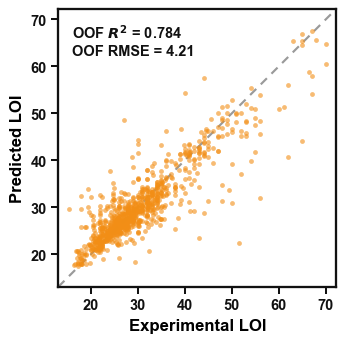

In [4]:
# 4. Figure 4e：LOI（当前最佳 ExtraTrees）
plot_regression_oof('LOI', 'Experimental LOI', 'Predicted LOI', 'figure4e_loi_oof.svg')

Tg | LightGBM | n=518 | OOF R²=0.8802 | OOF RMSE=26.0953


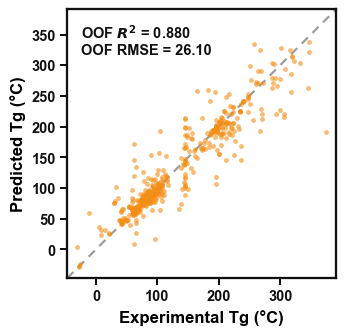

In [5]:
# 5. Figure 4c：Tg（当前最佳 LightGBM）
plot_regression_oof('Tg', 'Experimental T$_g$ (°C)', 'Predicted T$_g$ (°C)', 'figure4c_tg_oof.svg')

T5 | XGBoost | n=584 | OOF R²=0.7071 | OOF RMSE=41.6527


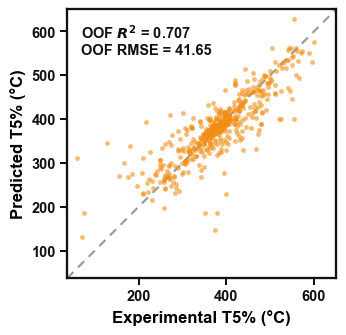

In [6]:
# 6. Figure 4d：T5（当前最佳 XGBoost）
plot_regression_oof('T5', 'Experimental T$_{5\%}$ (°C)', 'Predicted T$_{5\%}$ (°C)', 'figure4d_t5_oof.svg')

In [7]:
# 7. 重建 UL94 XGBoost 的 OOF 概率（仅使用已保存的各外层折最优参数）
UL94_INPUT = PROJECT_ROOT / 'results' / 'ul94_motif_select' / 'best_improved_final_features_with_target.csv'
ul94_table = pd.read_csv(UL94_INPUT)
if 'UL-94' not in ul94_table.columns:
    raise KeyError(f'未在 {UL94_INPUT} 中找到 UL-94 列。')
ul94_table = ul94_table.loc[ul94_table['UL-94'].notna()].copy()
feature_candidates = ul94_table.drop(columns=['UL-94'])
feature_columns = [c for c in feature_candidates.select_dtypes(include=[np.number]).columns if c not in METADATA_COLUMNS]
X_ul94 = ul94_table[feature_columns].astype(np.float32, copy=False)
labels_ul94 = ul94_table['UL-94'].astype(str)
expected_labels = {'V-0', 'non-V-0'}
if set(labels_ul94.unique()) != expected_labels:
    raise RuntimeError(f'UL94 标签类别发生变化：{sorted(labels_ul94.unique())}')
# 与 UL94 模型比较完全一致：V-0=1（正类），non-V-0=0。
y_ul94 = pd.Series((labels_ul94 == 'V-0').astype(int), index=X_ul94.index)
y_is_v0 = y_ul94.copy()
positive_class = 'V-0'
positive_index = 1

with (MODEL_COMPARE_DIR / 'UL94' / 'best_params.json').open(encoding='utf-8') as handle:
    fold_settings = json.load(handle)['XGBoost']['best_params_by_fold']
params_by_fold = {int(item['fold']): item['best_params'] for item in fold_settings}
if set(params_by_fold) != set(range(1, OUTER_SPLITS + 1)):
    raise RuntimeError(f'UL94 XGBoost 每折参数不完整：{sorted(params_by_fold)}')

outer_cv = StratifiedKFold(n_splits=OUTER_SPLITS, shuffle=True, random_state=RANDOM_STATE)
oof_probability = np.full(len(X_ul94), np.nan, dtype=float)
oof_fold = np.full(len(X_ul94), -1, dtype=int)
for fold, (train_idx, valid_idx) in enumerate(outer_cv.split(X_ul94, y_ul94), start=1):
    # 与模型比较 notebook 的 Pipeline 第一阶段一致：常数 0 填补缺失值。
    imputer = SimpleImputer(strategy='constant', fill_value=0)
    x_train = imputer.fit_transform(X_ul94.iloc[train_idx])
    x_valid = imputer.transform(X_ul94.iloc[valid_idx])
    fold_params = {key.removeprefix('model__'): value for key, value in params_by_fold[fold].items()}
    estimator = XGBClassifier(random_state=RANDOM_STATE, n_jobs=XGB_N_JOBS, verbosity=0,
                              eval_metric='logloss', tree_method='hist', **fold_params)
    estimator.fit(x_train, y_ul94.iloc[train_idx])
    oof_probability[valid_idx] = estimator.predict_proba(x_valid)[:, positive_index]
    oof_fold[valid_idx] = fold

if np.isnan(oof_probability).any() or (oof_fold < 1).any():
    raise RuntimeError('UL94 OOF 概率未覆盖全部样本。')
saved_predictions = pd.read_csv(MODEL_COMPARE_DIR / 'UL94' / 'cv_predictions.csv')
saved_folds = saved_predictions['XGBoost_fold'].astype(int).to_numpy()
if not np.array_equal(saved_folds, oof_fold):
    raise RuntimeError('重建的 UL94 外层折与已保存 XGBoost_fold 不一致。')

ul94_oof = pd.DataFrame({
    'sample_index': ul94_table.index.to_numpy(), 'true_value': labels_ul94.to_numpy(),
    'true_is_V-0': y_is_v0.to_numpy(), 'outer_fold': oof_fold,
    'XGBoost_predicted_label': saved_predictions['XGBoost'].to_numpy(),
    'XGBoost_probability_V-0': oof_probability,
})
ul94_oof.to_csv(OUTPUT_DIR / 'ul94_xgboost_oof_probabilities.csv', index=False, encoding='utf-8-sig')
print(f'UL94 OOF probability saved: {len(ul94_oof)} samples; positive class = {positive_class}')
ul94_oof.head()

UL94 OOF probability saved: 459 samples; positive class = V-0


,sample_index,true_value,true_is_V-0,outer_fold,XGBoost_predicted_label,XGBoost_probability_V-0
0,0,non-V-0,0,2,non-V-0,0.006796
1,1,non-V-0,0,3,non-V-0,0.006579
2,2,non-V-0,0,5,non-V-0,0.001521
3,3,non-V-0,0,1,non-V-0,0.003023
4,4,non-V-0,0,5,V-0,0.962882


UL94 | XGBoost | n=459 | pooled OOF AUC=0.8556


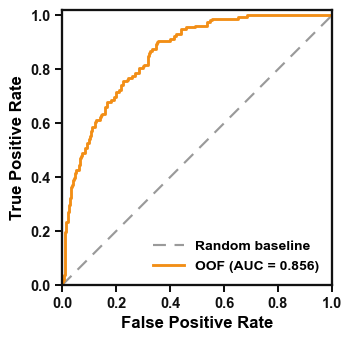

,task,model,n_oof_samples,OOF_R2,OOF_RMSE,OOF_ROC_AUC
0,LOI,ExtraTrees,948,0.784040,4.206924,NaN
1,Tg,LightGBM,518,0.880155,26.095304,NaN
2,T5,XGBoost,584,0.707088,41.652656,NaN
3,UL94,XGBoost,459,NaN,NaN,0.855577


In [8]:
# 8. Figure 4f：UL94 的 pooled OOF ROC（当前最佳 XGBoost）
fpr, tpr, _ = roc_curve(ul94_oof['true_is_V-0'], ul94_oof['XGBoost_probability_V-0'])
oof_auc = float(auc(fpr, tpr))

fig, ax = plt.subplots(figsize=(PLOT['width_in'], PLOT['height_in']))
fig.patch.set_alpha(0)
ax.plot([0, 1], [0, 1], linestyle=(0, (6, 4)), color=PLOT['reference_color'],
        linewidth=PLOT['reference_line_width'], label='Random baseline', zorder=1)
ax.plot(fpr, tpr, color=PLOT['point_color'], linewidth=PLOT['roc_line_width'],
        label=f'OOF (AUC = {oof_auc:.3f})', zorder=2)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)
ax.set_aspect('equal', adjustable='box')
ax.set_xlabel('False Positive Rate', fontsize=PLOT['axis_label_size'], fontweight='bold')
ax.set_ylabel('True Positive Rate', fontsize=PLOT['axis_label_size'], fontweight='bold')
legend = ax.legend(loc='lower right', frameon=False, fontsize=PLOT['legend_size'], handlelength=2.2)
for text in legend.get_texts():
    text.set_fontweight('bold')
style_axes(ax)
fig.tight_layout(pad=0.35)

OOF_SUMMARY.append({'task': 'UL94', 'model': BEST_MODELS['UL94'], 'n_oof_samples': len(ul94_oof),
                    'OOF_R2': np.nan, 'OOF_RMSE': np.nan, 'OOF_ROC_AUC': oof_auc})
summary = pd.DataFrame(OOF_SUMMARY)
summary.to_csv(OUTPUT_DIR / 'figure4_oof_metrics_summary.csv', index=False, encoding='utf-8-sig')
print(f'UL94 | {BEST_MODELS["UL94"]} | n={len(ul94_oof)} | pooled OOF AUC={oof_auc:.4f}')
save_and_show(fig, 'figure4f_ul94_oof_roc.svg')
summary